In [2]:
import pandas as pd

df=pd.read_csv('vgsales.csv')

data = df.dropna()

nullyear = df[df['Year'].isnull()]

In [3]:

df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [4]:
df['Publisher'].unique().size

579

<Axes: >

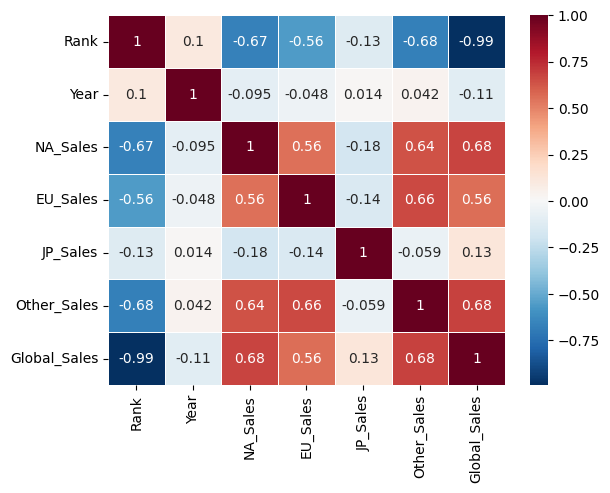

In [ ]:
from sklearn import preprocessing
import seaborn as sb
pearsoncorr=df.corr(method='kendall' ,numeric_only=True)
sb.heatmap(pearsoncorr,
            xticklabels=pearsoncorr.columns,
            yticklabels=pearsoncorr.columns,
            cmap='RdBu_r',
            annot=True,
            linewidth=0.5)

In [30]:

# Calculate the correlation
df.corr(numeric_only=True)["Year"]

Rank            0.178814
Year            1.000000
NA_Sales       -0.091402
EU_Sales        0.006014
JP_Sales       -0.169316
Other_Sales     0.041058
Global_Sales   -0.074735
Name: Year, dtype: float64

In [31]:

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor 
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

x = data.drop(['Year'], axis=1)
y = data['Year']


label_encoders = {}
for col in ['Name', 'Platform', 'Genre', 'Publisher']:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    label_encoders[col] = le

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
result = r2_score(y_test, y_pred)
print(result * 100)



87.97020166522498


In [32]:
df = pd.get_dummies(df, drop_first=True)
nullyear = df[df['Year'].isnull()].copy()  # Keep a copy
x1 = nullyear.drop(['Year'], axis=1)
x1 = x1.reindex(columns=x_train.columns, fill_value=0)


predicted_years = model.predict(x1)

nullyear['preyear'] = predicted_years
nullyear['preyear']=nullyear['preyear'].round()
nullyear

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Name_.hack//G.U. Vol.1//Rebirth,Name_.hack//G.U. Vol.2//Reminisce,Name_.hack//G.U. Vol.2//Reminisce (jp sales),...,Publisher_bitComposer Games,Publisher_dramatic create,Publisher_fonfun,Publisher_iWin,Publisher_id Software,Publisher_imageepoch Inc.,Publisher_inXile Entertainment,"Publisher_mixi, Inc",Publisher_responDESIGN,preyear
179,180,NaN,4.26,0.26,0.01,0.71,5.23,False,False,False,...,False,False,False,False,False,False,False,False,False,1982.0
377,378,NaN,0.59,2.36,0.04,0.51,3.49,False,False,False,...,False,False,False,False,False,False,False,False,False,1982.0
431,432,NaN,1.86,1.02,0.00,0.29,3.17,False,False,False,...,False,False,False,False,False,False,False,False,False,1982.0
470,471,NaN,1.57,1.02,0.00,0.41,3.00,False,False,False,...,False,False,False,False,False,False,False,False,False,1982.0
607,608,NaN,2.36,0.14,0.00,0.03,2.53,False,False,False,...,False,False,False,False,False,False,False,False,False,1982.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16307,16310,NaN,0.01,0.00,0.00,0.00,0.01,False,False,False,...,False,False,False,False,False,False,False,False,False,1985.0
16327,16330,NaN,0.01,0.00,0.00,0.00,0.01,False,False,False,...,False,False,False,False,False,False,False,False,False,1985.0
16366,16369,NaN,0.01,0.00,0.00,0.00,0.01,False,False,False,...,False,False,False,False,False,False,False,False,False,1985.0
16427,16430,NaN,0.01,0.00,0.00,0.00,0.01,False,False,False,...,False,False,False,False,False,False,False,False,False,1985.0


<Axes: xlabel='Year', ylabel='Count'>

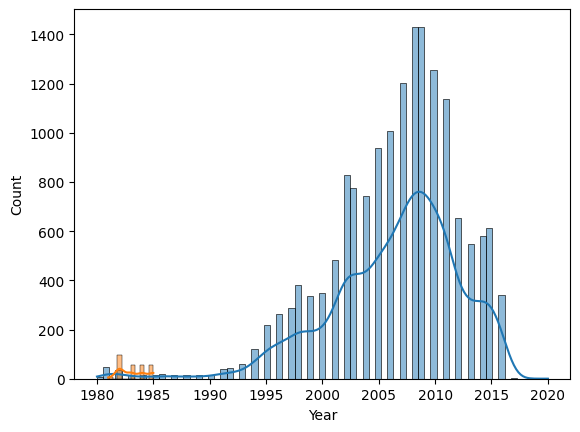

In [33]:
import seaborn as sns

sns.histplot(data['Year'], kde=True)
sns.histplot(nullyear['preyear'], kde=True)


In [34]:
nullPublisher = data[data['Publisher'].isnull()]
nullPublisher.shape

(0, 11)

In [35]:
data

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [36]:
x1 = data.drop(['Publisher'], axis=1)
y1 = data['Publisher'].astype(str)

label_encoders = {}
for col in ['Name', 'Platform', 'Genre']:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    label_encoders[col] = le

le_publisher = LabelEncoder()
y1_encoded = le_publisher.fit_transform(y1)

x_train, x_test, y1_train, y1_test = train_test_split(x, y1_encoded, test_size=0.2)

model1 = RandomForestRegressor()
model1.fit(x_train, y1_train)
y1_pred = model1.predict(x_test)
result = r2_score(y1_test, y1_pred)
result * 100

99.99993684617777

In [37]:
nullPublisher = df[df['Publisher'].isnull()]
x1 = nullPublisher.drop(['Publisher','Year'], axis=1)


label_encoders = {}
for col in ['Name', 'Platform', 'Genre']:
    le = LabelEncoder()
    x1[col] = le.fit_transform(x1[col])
    label_encoders[col] = le

predicted_publishers = modely1.predict(x1)





KeyError: 'Publisher'